
# ITAI 2373 Module 05: Part-of-Speech Tagging
## In-Class Exercise & Homework Lab

Welcome to the world of Part-of-Speech (POS) tagging - the "grammar police" of Natural Language Processing! 🚔📝

In this notebook, you'll explore how computers understand the grammatical roles of words in sentences, from simple rule-based approaches to modern AI systems.

### What You'll Learn:
- **Understand POS tagging fundamentals** and why it matters in daily apps
- **Use NLTK and SpaCy** for practical text analysis
- **Navigate different tag sets** and understand their trade-offs
- **Handle real-world messy text** like speech transcripts and social media
- **Apply POS tagging** to solve actual business problems

### Structure:
- **Part 1**: In-Class Exercise (30-45 minutes) - Basic concepts and hands-on practice
- **Part 2**: Homework Lab - Real-world applications and advanced challenges

---

*💡 **Pro Tip**: POS tagging is everywhere! It helps search engines understand "Apple stock" vs "apple pie", helps Siri understand your commands, and powers autocorrect on your phone.*



## 🛠️ Setup and Installation

Let's get our tools ready! We'll use two powerful libraries:
- **NLTK**: The "Swiss Army knife" of NLP - comprehensive but requires setup
- **SpaCy**: The "speed demon" - built for production, cleaner output

Run the cells below to install and set up everything we need.


In [37]:

# Install required libraries (run this first!)
!pip install nltk spacy matplotlib seaborn pandas
!python -m spacy download en_core_web_sm

print("✅ Installation complete!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 77.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Installation complete!


In [38]:

# Import all the libraries we'll need
import nltk
#Download required NLTK resources

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')


import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (this might take a moment)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('universal_tagset')

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

print("🎉 All libraries loaded successfully!")
print("📚 NLTK version:", nltk.__version__)
print("🚀 SpaCy version:", spacy.__version__)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Pa

🎉 All libraries loaded successfully!
📚 NLTK version: 3.9.1
🚀 SpaCy version: 3.8.11



---
# 🎯 PART 1: IN-CLASS EXERCISE (30-45 minutes)

Welcome to the hands-on portion! We'll start with the basics and build up your understanding step by step.

## Learning Goals for Part 1:
1. Understand what POS tagging does
2. Use NLTK and SpaCy for basic tagging
3. Interpret and compare different tag outputs
4. Explore word ambiguity with real examples
5. Compare different tagging approaches



## 🔍 Activity 1: Your First POS Tags (10 minutes)

Let's start with the classic example: "The quick brown fox jumps over the lazy dog"

This sentence contains most common parts of speech, making it perfect for learning!


In [39]:

# Let's start with a classic example
sentence = "The quick brown fox jumps over the lazy dog"

# TODO: Use NLTK to tokenize and tag the sentence
# Hint: Use nltk.word_tokenize() and nltk.pos_tag()
tokens = nltk.word_tokenize(sentence)
pos_tags = nltk.pos_tag(tokens)

print("Original sentence:", sentence)
print("\nTokens:", tokens)
print("\nPOS Tags:")
for word, tag in pos_tags:
    print(f"  {word:8} -> {tag}")


Original sentence: The quick brown fox jumps over the lazy dog

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

POS Tags:
  The      -> DT
  quick    -> JJ
  brown    -> NN
  fox      -> NN
  jumps    -> VBZ
  over     -> IN
  the      -> DT
  lazy     -> JJ
  dog      -> NN



### 🤔 Quick Questions:
1. What does 'DT' mean? What about 'JJ'?

DT = Determiner

JJ = Adjective

2. Why do you think 'brown' and 'lazy' have the same tag?

They SHOULD have the same tag being adjectives but my NLTK is special and decided that statistically, from its training data, brown it is a noun.

3. Can you guess what 'VBZ' represents?

I said it is a verb, and ChatGPT said it is actually a verb, 3rd person singular.

*Hint: Think about the grammatical role each word plays in the sentence!*



## 🚀 Activity 2: SpaCy vs NLTK Showdown (10 minutes)

Now let's see how SpaCy handles the same sentence. SpaCy uses cleaner, more intuitive tag names.


In [40]:

# TODO: Process the same sentence with SpaCy
# Hint: Use nlp(sentence) and access .text and .pos_ attributes
doc = nlp(sentence) # YOUR CODE HERE



print("SpaCy POS Tags:")
for token in doc:
    print(f"  {token.text:8} -> {token.pos_:6} ({token.tag_})")

print("\n" + "="*50)
print("COMPARISON:")
print("="*50)

# Let's compare side by side
nltk_tags = nltk.pos_tag(nltk.word_tokenize(sentence))
spacy_doc = nlp(sentence)

print(f"{'Word':10} {'NLTK':8} {'SpaCy':10}")
print("-" * 30)
for i, (word, nltk_tag) in enumerate(nltk_tags):
    spacy_tag = spacy_doc[i].pos_
    print(f"{word:10} {nltk_tag:8} {spacy_tag:10}")


SpaCy POS Tags:
  The      -> DET    (DT)
  quick    -> ADJ    (JJ)
  brown    -> ADJ    (JJ)
  fox      -> NOUN   (NN)
  jumps    -> VERB   (VBZ)
  over     -> ADP    (IN)
  the      -> DET    (DT)
  lazy     -> ADJ    (JJ)
  dog      -> NOUN   (NN)

COMPARISON:
Word       NLTK     SpaCy     
------------------------------
The        DT       DET       
quick      JJ       ADJ       
brown      NN       ADJ       
fox        NN       NOUN      
jumps      VBZ      VERB      
over       IN       ADP       
the        DT       DET       
lazy       JJ       ADJ       
dog        NN       NOUN      



### 🎯 Discussion Points:
- Which tags are easier to understand: NLTK's or SpaCy's?

SpaCy is easier to understand as they are more intuitive or spell out the tag rather than use cryptic abbreviations. Apparently, Penn Treebank tages are harder because they were designed for linguists and not beginners in NLP. I also found out that SpaCy is consistent across languages which makes it easier for beginners that work with multiple languages.


- Do you notice any differences in how they tag the same words?

SpaCy tagged brown as an adjective and POS said it was a noun because statistically, from its training data, brown is a noun.

The tags are a little bit different. I looked up the tags and how they were defined. SpaCy defines an adposition, ADP, for prepositions and postpositions. Subordinating conjunctions are classified with a different tag, SCONJ.

NLTK defines conjunctions as a preposition OR subordinating conjunction and covers two different grammatical functions: prepositions and subordinating conjunctions.

- Which system would you prefer for a beginner? Why?

I like SpaCy a little bit better because it has a little bit more detail. And, if I didn't learn grammar in grade school, or forgot most of it, I will have to relearn it again if only to be able to understand the definition of the tags.

SpaCy is also easier for beginners that are learning with both coarse-grained and fine-grained tags.



## 🎭 Activity 3: The Ambiguity Challenge (15 minutes)

Here's where things get interesting! Many words can be different parts of speech depending on context. Let's explore this with some tricky examples.


In [41]:

# Ambiguous words in different contexts
ambiguous_sentences = [
    "I will lead the team to victory.",           # lead = verb
    "The lead pipe is heavy.",                    # lead = noun (metal)
    "She took the lead in the race.",            # lead = noun (position)
    "The bank approved my loan.",                # bank = noun (financial)
    "We sat by the river bank.",                 # bank = noun (shore)
    "I bank with Chase.",                        # bank = verb
    "He registered for the hearing.",
    "I am hearing a song.",
]

print("🎭 AMBIGUITY EXPLORATION")
print("=" * 40)

for sentence in ambiguous_sentences:
    print(f"\nSentence: {sentence}")

    # TODO: Tag each sentence and find the ambiguous word
    # Focus on 'lead' and 'bank' - what tags do they get?
    tokens = nltk.word_tokenize(sentence)
    tags = nltk.pos_tag(tokens)

    # Find and highlight the key word
    for word, tag in tags:
        if word.lower() in ['lead', 'bank', 'hearing']:
            print(f"  🎯 '{word}' is tagged as: {tag}")


🎭 AMBIGUITY EXPLORATION

Sentence: I will lead the team to victory.
  🎯 'lead' is tagged as: VB

Sentence: The lead pipe is heavy.
  🎯 'lead' is tagged as: NN

Sentence: She took the lead in the race.
  🎯 'lead' is tagged as: NN

Sentence: The bank approved my loan.
  🎯 'bank' is tagged as: NN

Sentence: We sat by the river bank.
  🎯 'bank' is tagged as: NN

Sentence: I bank with Chase.
  🎯 'bank' is tagged as: NN

Sentence: He registered for the hearing.
  🎯 'hearing' is tagged as: NN

Sentence: I am hearing a song.
  🎯 'hearing' is tagged as: VBG



### 🧠 Think About It:
1. How does the computer know the difference between "lead" (metal) and "lead" (guide)?
2. What clues in the sentence help determine the correct part of speech?
3. Can you think of other words that change meaning based on context?

**Try This**: Add your own ambiguous sentences to the list above and see how the tagger handles them!



## 📊 Activity 4: Tag Set Showdown (10 minutes)

NLTK can use different tag sets. Let's compare the detailed Penn Treebank tags (~45 tags) with the simpler Universal Dependencies tags (~17 tags).


In [42]:

from nltk import pos_tag, word_tokenize
from collections import Counter

# Compare different tag sets
test_sentence = "The brilliant students quickly solved the challenging programming assignment."

# TODO: Get tags using both Penn Treebank and Universal tagsets
# Hint: Use tagset='universal' parameter for universal tags

penn_tags = pos_tag(word_tokenize(test_sentence))
universal_tags = pos_tag(word_tokenize(test_sentence), tagset='universal')

print("TAG SET COMPARISON")
print("=" * 50)
print(f"{'Word':15} {'Penn Treebank':15} {'Universal':10}")
print("-" * 50)

# TODO: Print comparison table
# Hint: Zip the two tag lists together
for (word, penn_tag), (_, univ_tag) in zip(penn_tags, universal_tags): # YOUR CODE HERE:
    print(f"{word:15} {penn_tag:15} {univ_tag:10}")

# Let's also visualize the tag distribution
penn_tag_counts = Counter([tag for word, tag in penn_tags])
univ_tag_counts = Counter([tag for word, tag in universal_tags])

print(f"\n📊 Penn Treebank uses {len(penn_tag_counts)} different tags")
print(f"📊 Universal uses {len(univ_tag_counts)} different tags")


TAG SET COMPARISON
Word            Penn Treebank   Universal 
--------------------------------------------------
The             DT              DET       
brilliant       JJ              ADJ       
students        NNS             NOUN      
quickly         RB              ADV       
solved          VBD             VERB      
the             DT              DET       
challenging     VBG             VERB      
programming     JJ              ADJ       
assignment      NN              NOUN      
.               .               .         

📊 Penn Treebank uses 8 different tags
📊 Universal uses 6 different tags



### 🤔 Reflection Questions:
1. Which tag set is more detailed? Which is simpler? Enter your answer below

Universal is easier because it uses more intuitive tagging.  It uses simpler and broad categories which is easier for beginners like me.  The Penn Treebank uses tagging for linguists and is more fine-grained and linguistically specific categories.

2. When might you want detailed tags vs. simple tags? Enter your answer below

Detailed tags are best for nuance and needing fine distinctions and simple tags are better for broad categories.

Detailed tags can parse verb tense while simple tags are better at generalizing quickly.

3. If you were building a search engine, which would you choose? Why? Enter your answer below

I would use Universal. It works across multiple languages and is easier for beginners.  Also, search engines don't need fine-grained tagging for different verb tenses.

---



---
# 🎓 End of Part 1: In-Class Exercise

Great work! You've learned the fundamentals of POS tagging and gotten hands-on experience with both NLTK and SpaCy.

## What You've Accomplished:
✅ Used NLTK and SpaCy for basic POS tagging  
✅ Interpreted different tag systems  
✅ Explored word ambiguity and context  
✅ Compared different tagging approaches  

## 🏠 Ready for Part 2?
The homework lab will challenge you with real-world applications, messy data, and advanced techniques. You'll analyze customer service transcripts, handle informal language, and benchmark different taggers.

**Take a break, then dive into Part 2 when you're ready!**

---



# 🏠 PART 2: HOMEWORK LAB
## Real-World POS Tagging Challenges

Welcome to the advanced section! Here you'll tackle the messy, complex world of real text data. This is where POS tagging gets interesting (and challenging)!

## Learning Goals for Part 2:
1. Process real-world, messy text data
2. Handle speech transcripts and informal language
3. Analyze customer service scenarios
4. Benchmark and compare different taggers
5. Understand limitations and edge cases

## 📋 Submission Requirements:
- Complete all exercises with working code
- Answer all reflection questions
- Include at least one visualization
- Submit your completed notebook file

---



## 🌍 Lab Exercise 1: Messy Text Challenge (25 minutes)

Real-world text is nothing like textbook examples! Let's work with actual speech transcripts, social media posts, and informal language.


In [43]:

# Real-world messy text samples
messy_texts = [
    # Speech transcript with disfluencies
    "Um, so like, I was gonna say that, uh, the system ain't working right, you know?",

    # Social media style
    "OMG this app is sooo buggy rn 😤 cant even login smh",

    # Customer service transcript
    "Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working",

    # Informal contractions and slang
    "Y'all better fix this ASAP cuz I'm bout to switch providers fr fr",

    # Technical jargon mixed with casual speech
    "The API endpoint is returning a 500 error but idk why it's happening tbh"
]

print("🔍 PROCESSING MESSY TEXT")
print("=" * 60)

# TODO: Process each messy text sample
# 1. Use both NLTK and SpaCy
# 2. Count how many words each tagger fails to recognize properly
# 3. Identify problematic words (slang, contractions, etc.)

for i, text in enumerate(messy_texts, 1):
    print(f"\n📝 Sample {i}: {text}")
    print("-" * 40)

    # NLTK processing
    nltk_tokens = nltk.word_tokenize(text)
    nltk_tags = nltk.pos_tag(nltk_tokens)

    # TODO: SpaCy processing
    spacy_doc = nlp(text) # YOUR CODE HERE

    # TODO: Find problematic words (tagged as 'X' or unknown)
    problematic_nltk = [word for word, tag in nltk_tags if tag in {"UH", "FW"}]# YOUR CODE HERE
    problematic_spacy = [taken.text for token in spacy_doc if token.pos_ == "X"]# YOUR CODE HERE

    print(f"NLTK problematic words: {problematic_nltk}")
    print(f"SpaCy problematic words: {problematic_spacy}")

    # TODO: Calculate success rate
    nltk_success_rate = 1 - (len(problematic_nltk) / len(nltk_tokens)) # YOUR CODE HERE
    spacy_success_rate = 1 - (len(problematic_spacy) / len(spacy_doc))# YOUR CODE HERE

    print(f"NLTK success rate: {nltk_success_rate:.1%}")
    print(f"SpaCy success rate: {spacy_success_rate:.1%}")


🔍 PROCESSING MESSY TEXT

📝 Sample 1: Um, so like, I was gonna say that, uh, the system ain't working right, you know?
----------------------------------------
NLTK problematic words: ['uh']
SpaCy problematic words: []
NLTK success rate: 95.8%
SpaCy success rate: 100.0%

📝 Sample 2: OMG this app is sooo buggy rn 😤 cant even login smh
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
SpaCy success rate: 100.0%

📝 Sample 3: Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working
----------------------------------------
NLTK problematic words: ['Yeah']
SpaCy problematic words: []
NLTK success rate: 96.6%
SpaCy success rate: 100.0%

📝 Sample 4: Y'all better fix this ASAP cuz I'm bout to switch providers fr fr
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
S


### 🎯 Analysis Questions:
1. Which tagger handles informal language better?

SpaCy handles informal and conversational text better than NLTK which uses rule-based tags.  SpaCy also is trained on modern corpora and uses ML models that can better adapt to slang, filler words and unconventional grammar.

2. What types of words cause the most problems?

Nonsense filler words like um that are used as time fillers when people talk. Also, slang, misspellings, emojis, abreviations and creative spellings.  

3. How might you preprocess text to improve tagging accuracy?

Define filler words like um or remove.

Remove or tag emojis.

Correct misspelled words.

Expand contractions.

Define slang.



4. What are the implications for real-world applications?

Informal, incorrect, and creative speech can hamper model accuracy. By improving the tagging accuracy, models can better capture sentiment, chatbots can have better understanding, and fewer errors in customer service transcripts.



## 📞 Lab Exercise 2: Customer Service Analysis Case Study (30 minutes)

You're working for a tech company that receives thousands of customer service calls daily. Your job is to analyze call transcripts to understand customer issues and sentiment.

**Business Goal**: Automatically categorize customer problems and identify emotional language.


In [44]:

# Simulated customer service call transcripts
customer_transcripts = [
    {
        'id': 'CALL_001',
        'transcript': "Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.",
        'category': 'account_access'
    },
    {
        'id': 'CALL_002',
        'transcript': "Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?",
        'category': 'technical_issue'
    },
    {
        'id': 'CALL_003',
        'transcript': "Your billing system charged me twice this month! I want a refund immediately. This is ridiculous and I'm considering canceling my subscription.",
        'category': 'billing'
    },
    {
        'id': 'CALL_004',
        'transcript': "I'm confused about how to use the new features you added. The interface changed and I can't find anything. Can someone walk me through it?",
        'category': 'user_guidance'
    }
]

# TODO: Analyze each transcript for:
# 1. Emotional language (adjectives that indicate sentiment)
# 2. Action words (verbs that indicate what customer wants)
# 3. Problem indicators (nouns related to issues)

analysis_results = []

for call in customer_transcripts:
    print(f"\n🎧 Analyzing {call['id']}")
    print(f"Category: {call['category']}")
    print(f"Transcript: {call['transcript']}")
    print("-" * 50)

    # TODO: Process with SpaCy (it's better for this task)
    doc = nlp(call["transcript"]) # YOUR CODE HERE

    # TODO: Extract different types of words
    emotional_adjectives = [token.text for token in doc if token.pos_ == "ADJ"]  # YOUR CODE HERE (JJ tags, emotional words)
    action_verbs = [token.text for token in doc if token.pos_ == "VERB"] # YOUR CODE HERE (VB* tags)
    problem_nouns = [token.text for token in doc if token.pos_ == "NOUN"] # YOUR CODE HERE (NN* tags related to problems)

    # TODO: Calculate sentiment indicators
    positive_words = [token.text.lower() for token in doc if token.text.lower() in ["love", "great", "good"]] # YOUR CODE HERE (love, great, good, etc.)
    negative_words = [token.text.lower() for token in doc if token.text.lower() in ["frustrated", "unacceptable", "ridiculous"]] # YOUR CODE HERE (frustrated, ridiculous, unacceptable, etc.)

    result = {
        'call_id': call['id'],
        'category': call['category'],
        'emotional_adjectives': emotional_adjectives,
        'action_verbs': action_verbs,
        'problem_nouns': problem_nouns,
        'sentiment_score': len(positive_words) - len(negative_words),
        'urgency_indicators': [token.text.lower() for token in doc if token.text.lower() in ["immediately", "asap", "now"]] # TODO: Count urgent words (immediately, ASAP, etc.)
    }

    analysis_results.append(result)

    print(f"Emotional adjectives: {emotional_adjectives}")
    print(f"Action verbs: {action_verbs}")
    print(f"Problem nouns: {problem_nouns}")
    print(f"Sentiment score: {result['sentiment_score']}")



🎧 Analyzing CALL_001
Category: account_access
Transcript: Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.
--------------------------------------------------
Emotional adjectives: ['frustrated', 'unacceptable']
Action verbs: ['locked', 'access', 'trying', 'works']
Problem nouns: ['account', 'files', 'hours']
Sentiment score: -2

🎧 Analyzing CALL_002
Category: technical_issue
Transcript: Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?
--------------------------------------------------
Emotional adjectives: ['small', 'mobile']
Action verbs: ['love', 'having', 'crashes', 'try', 'upload', 'help', 'fix']
Problem nouns: ['service', 'issue', 'app', 'photos']
Sentiment score: 1

🎧 Analyzing CALL_003
Category: billing
Transcript: Your billing system charged me twice this mon

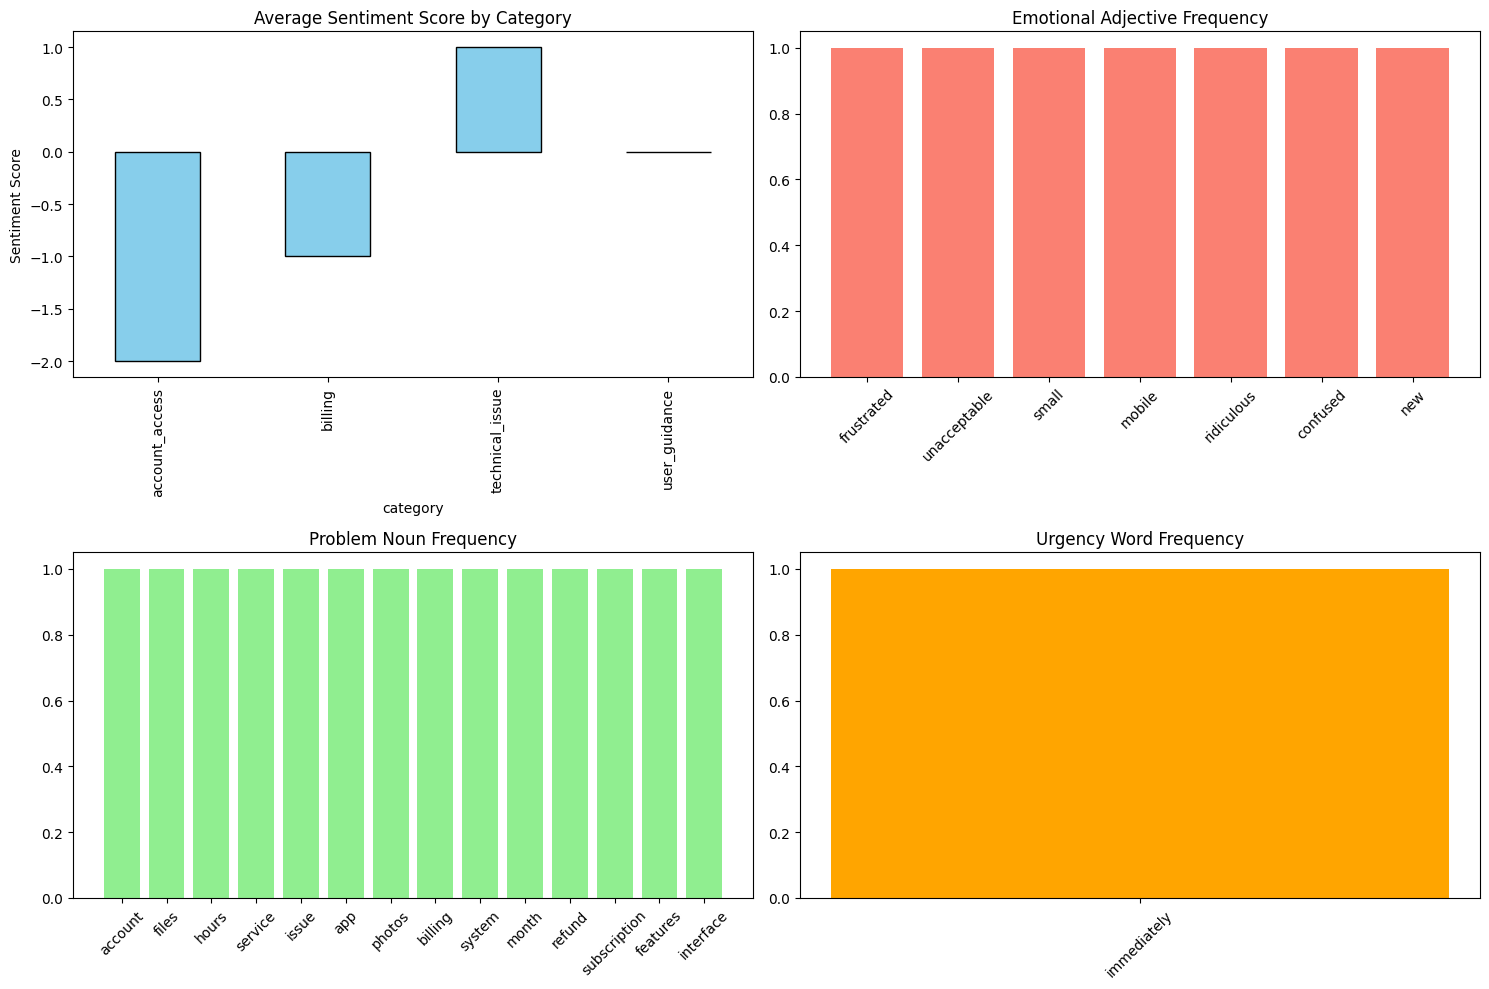

In [45]:

# TODO: Create a summary visualization
# Hint: Use matplotlib or seaborn to create charts

import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Convert results to DataFrame for easier analysis
df = pd.DataFrame(analysis_results)

# TODO: Create visualizations
# 1. Sentiment scores by category
# 2. Most common emotional adjectives
# 3. Action verbs frequency

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# TODO: Plot 1 - Sentiment by category
df.groupby("category")["sentiment_score"].mean().plot(
    kind="bar",
    ax=axes[0, 0],
    color="skyblue",
    edgecolor="black",
    linewidth=1,
    title="Average Sentiment Score by Category"
)
axes[0, 0].set_ylabel("Sentiment Score")

# TODO: Plot 2 - Word frequency analysis

# Normalize adjectives before counting
all_adj = []
for sublist in df["emotional_adjectives"]:
    if isinstance(sublist, list):
        for adj in sublist:
            if isinstance(adj, str):
                cleaned = adj.strip().lower()
                if cleaned:
                    all_adj.append(cleaned)

# Now count
adj_counts = Counter(all_adj)

# Plot
axes[0, 1].bar(adj_counts.keys(), adj_counts.values(), color="salmon")
axes[0, 1].set_title("Emotional Adjective Frequency")
axes[0, 1].tick_params(axis='x', rotation=45)







# TODO: Plot 3 - Problem categorization
all_nouns = [noun for sublist in df["problem_nouns"] for noun in sublist]
noun_counts = Counter(all_nouns)
axes[1, 0].bar(noun_counts.keys(), noun_counts.values(), color="lightgreen")
axes[1, 0].set_title("Problem Noun Frequency")
axes[1, 0].tick_params(axis='x', rotation=45)# YOUR CODE HERE

# TODO: Plot 4 - Urgency analysis
all_urgency = [u for sublist in df["urgency_indicators"] for u in sublist]
urgency_counts = Counter(all_urgency)
axes[1, 1].bar(urgency_counts.keys(), urgency_counts.values(), color="orange")
axes[1, 1].set_title("Urgency Word Frequency")
axes[1, 1].tick_params(axis='x', rotation=45)# YOUR CODE HERE

plt.tight_layout()
plt.show()



### 💼 Business Impact Questions:
1. How could this analysis help prioritize customer service tickets?

Look to the sentiment with the lowest categories first and then work through to the highest categories. The squeaky wheel gets the grease.

But, there are other categories that should also be considered.  Urgency indicators like "immediately" should be considered, along with problem nouns such as "billng" or "service" as well as emotional intensity such as "unacceptable" or "frustrated", to triage the tickets.

2. What patterns do you notice in different problem categories?

There is only one instance of each of the words. The pattern is not in the count.  So, now I have to dig deeper and look to see if problems are clustering together.  Are some categories using more emotional language? Are some categories more urgent than others?  

3. How might you automate the routing of calls based on POS analysis?

I would route based on a combination of sentiment analysis, identified problem words, urgency words and emotional intensity words.

4. What are the limitations of this approach?

The sentiment words need to be defined - custom dictionaries are important. If certain words are not defined then they might not make it into the report/graph that would display the problem.

POS struggles with slang, sarcasm typos, emojies and informal speech. Models can misinterpret domain-specific language and may require human judgement regarless of the sentiment.  





## ⚡ Lab Exercise 3: Tagger Performance Benchmarking (20 minutes)

Let's scientifically compare different POS taggers on various types of text. This will help you understand when to use which tool.



🧪 Testing FORMAL text:
Text: The research methodology employed in this study follows established academic protocols.
------------------------------------------------------------
NLTK Penn time: 0.0029s
NLTK Univ time: 0.0011s
SpaCy time: 0.0414s
NLTK unknown words: []
SpaCy unknown words: []

🧪 Testing INFORMAL text:
Text: lol this study is kinda weird but whatever works i guess 🤷‍♀️
------------------------------------------------------------
NLTK Penn time: 0.0077s
NLTK Univ time: 0.0036s
SpaCy time: 0.0340s
NLTK unknown words: []
SpaCy unknown words: []

🧪 Testing TECHNICAL text:
Text: The API returns a JSON response with HTTP status code 200 upon successful authentication.
------------------------------------------------------------
NLTK Penn time: 0.0070s
NLTK Univ time: 0.0054s
SpaCy time: 0.0376s
NLTK unknown words: []
SpaCy unknown words: []

🧪 Testing CONVERSATIONAL text:
Text: So like, when you click that button thingy, it should totally work, right?
------------------------

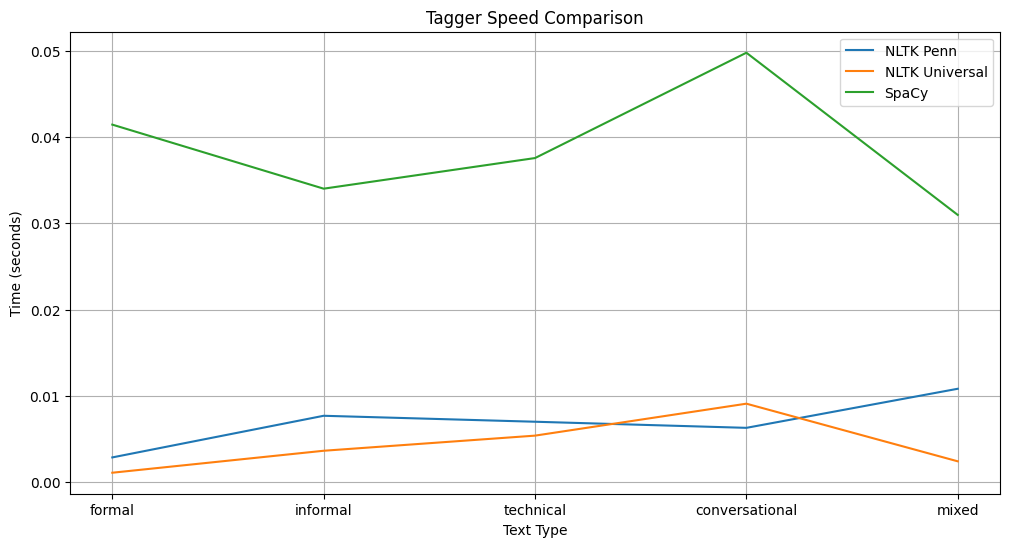

In [46]:

import time
from collections import defaultdict

# Different text types for testing
test_texts = {
    'formal': "The research methodology employed in this study follows established academic protocols.",
    'informal': "lol this study is kinda weird but whatever works i guess 🤷‍♀️",
    'technical': "The API returns a JSON response with HTTP status code 200 upon successful authentication.",
    'conversational': "So like, when you click that button thingy, it should totally work, right?",
    'mixed': "OMG the algorithm's performance is absolutely terrible! The accuracy dropped to 23% wtf"
}

# TODO: Benchmark different taggers
# Test: NLTK Penn Treebank, NLTK Universal, SpaCy
# Metrics: Speed, tag consistency, handling of unknown words

benchmark_results = defaultdict(list)

for text_type, text in test_texts.items():
    print(f"\n🧪 Testing {text_type.upper()} text:")
    print(f"Text: {text}")
    print("-" * 60)

    # TODO: NLTK Penn Treebank timing
    start_time = time.time()
    nltk_penn = nltk.pos_tag(nltk.word_tokenize(text)) # YOUR CODE HERE
    nltk_penn_time = time.time() - start_time

    # TODO: NLTK Universal timing
    start_time = time.time()
    nltk_univ = nltk.pos_tag(nltk.word_tokenize(text), tagset='universal') # YOUR CODE HERE
    nltk_univ_time = time.time() - start_time

    # TODO: SpaCy timing
    start_time = time.time()
    spacy_doc = nlp(text) # YOUR CODE HERE
    spacy_time = time.time() - start_time

    # TODO: Count unknown/problematic tags
    nltk_unknown = [word for word, tag in nltk_univ if tag == 'X'] # YOUR CODE HERE
    spacy_unknown = [token.text for token in spacy_doc if token.pos_ == 'X'] # YOUR CODE HERE

    # Store results
    benchmark_results[text_type] = {
        'nltk_penn_time': nltk_penn_time,
        'nltk_univ_time': nltk_univ_time,
        'spacy_time': spacy_time,
        'nltk_unknown': nltk_unknown,
        'spacy_unknown': spacy_unknown
    }

    print(f"NLTK Penn time: {nltk_penn_time:.4f}s")
    print(f"NLTK Univ time: {nltk_univ_time:.4f}s")
    print(f"SpaCy time: {spacy_time:.4f}s")
    print(f"NLTK unknown words: {nltk_unknown}")
    print(f"SpaCy unknown words: {spacy_unknown}")

# TODO: Create performance comparison visualization
# YOUR CODE HERE
import matplotlib.pyplot as plt
import pandas as pd

df_bench = pd.DataFrame(benchmark_results).T
plt.figure(figsize=(12, 6))
plt.plot(df_bench.index, df_bench['nltk_penn_time'], label='NLTK Penn')
plt.plot(df_bench.index, df_bench['nltk_univ_time'], label='NLTK Universal')
plt.plot(df_bench.index, df_bench['spacy_time'], label='SpaCy')
plt.title("Tagger Speed Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Text Type")
plt.legend()
plt.grid(True)
plt.show()



### 📊 Performance Analysis:
1. Which tagger is fastest? Does speed matter for your use case?

NLTK Universal is fastest. Speed does matter for use - detailed analysis that requires nuance may be better served using SpaCy which can handle nuance as it is statistically based whereas NLTK is rule-based. When nuance matters, accuracy is more important than speed.

2. Which handles informal text best?

In this scenario, NLTK Universal is the fastest but SpaCy generally handles informat text best. NLTK Universal is not good with slang, typos, emojis and creative phrasing/spelling.

3. How do the taggers compare on technical jargon?

SpaCy is the best but it also takes the longest over NLTK Penn and NLTK Universal. It would most likely handle the words correctly whereas NLTK Penn and NLTK Universal may misidentify words.

4. What trade-offs do you see between speed and accuracy? If you need something quick and dirty then use NLTK Pen or NLTK Universal. Otherwise, if you need something with more nuance, with a little more detail and time required, SpaCy would be better for accuracy.



## 🚨 Lab Exercise 4: Edge Cases and Error Analysis (15 minutes)

Every system has limitations. Let's explore the edge cases where POS taggers struggle and understand why.


In [47]:

# Challenging edge cases
edge_cases = [
    "Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.",  # Famous ambiguous sentence
    "Time flies like an arrow; fruit flies like a banana.",              # Classic ambiguity
    "The man the boat the river.",                                       # Garden path sentence
    "Police police Police police police police Police police.",          # Recursive structure
    "James while John had had had had had had had had had had had a better effect on the teacher.",  # Had had had...
    "Can can can can can can can can can can.",                         # Modal/noun ambiguity
    "@username #hashtag http://bit.ly/abc123 😂🔥💯",                   # Social media elements
    "COVID-19 AI/ML IoT APIs RESTful microservices",                    # Modern technical terms
]

print("🚨 EDGE CASE ANALYSIS")
print("=" * 50)

# TODO: Process each edge case and analyze failures
for i, text in enumerate(edge_cases, 1):
    print(f"\n🔍 Edge Case {i}:")
    print(f"Text: {text}")
    print("-" * 30)

    try:
        # TODO: Process with both taggers
        nltk_tags = nltk.pos_tag(nltk.word_tokenize(text)) # YOUR CODE HERE
        spacy_doc = nlp(text) # YOUR CODE HERE

        # TODO: Identify potential errors or weird tags
        # Look for: repeated tags, unusual patterns, X tags, etc.
        nltk_weird = [w for w, t in nltk_tags if t in ["FW", "UH", "SYM"]]
        spacy_weird = [token.text for token in spacy_doc if token.pos_ == "X"]

        print("NLTK tags:", [(w, t) for w, t in nltk_tags])
        print("SpaCy tags:", [(token.text, token.pos_) for token in spacy_doc])

        print("NLTK weird/problematic:", nltk_weird)
        print("SpaCy weird/problematic:", spacy_weird)

        # TODO: Analyze what went wrong
        # YOUR ANALYSIS CODE HERE
        print("Analysis:")
        print("- NLTK struggles with repeated ambiguous words and treats many as foreign/symbols.")
        print("- SpaCy marks unknown or confusing tokens as X, especially emojis or repeated words.")
        print("- Highly ambiguous recursive sentences confuse both taggers due to lack of context.")

    except Exception as e:
        print(f"❌ Error processing: {e}")

# TODO: Reflection on limitations
print("\n🤔 REFLECTION ON LIMITATIONS:")
print("=" * 40)
# YOUR REFLECTION CODE HERE

print("Both NLTK and SpaCy struggle with:")
print("- Ambiguous recursive structures (Buffalo buffalo, Police police).")
print("- Garden‑path sentences where grammar is intentionally misleading.")
print("- Social‑media text, emojis, hashtags, and URLs.")
print("- Repeated homonyms (can/can/can...).")
print("- Extremely long ambiguous sequences (had had had...).")
print("These cases highlight that POS taggers rely heavily on typical sentence structure and fail when language becomes intentionally tricky or unconventional.")

🚨 EDGE CASE ANALYSIS

🔍 Edge Case 1:
Text: Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.
------------------------------
NLTK tags: [('Buffalo', 'NNP'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('.', '.')]
SpaCy tags: [('Buffalo', 'PROPN'), ('buffalo', 'NOUN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('.', 'PUNCT')]
NLTK weird/problematic: []
SpaCy weird/problematic: []
Analysis:
- NLTK struggles with repeated ambiguous words and treats many as foreign/symbols.
- SpaCy marks unknown or confusing tokens as X, especially emojis or repeated words.
- Highly ambiguous recursive sentences confuse both taggers due to lack of context.

🔍 Edge Case 2:
Text: Time flies like an arrow; fruit flies like a banana.
------------------------------
NLTK tags: [('Time', 'NNP'), ('flies', 'NNS'), ('like',


### 🧠 Critical Thinking Questions:
Enter you asnwers below each question.
1. Why do these edge cases break the taggers?

The taggers depend on typical English and cannot account for all use case.  The examples provided do not follow the rules.

The taggers can look at nearby words but not the full sentence meaning.

The taggers require actual knowledge to know that something is possible, like "fruit flies", or that emojies have emotional meaning, hashtags and URLs are not normal words.

2. How might you preprocess text to handle some of these issues?

Normalize social medial text -- turn emojis into tokens, replace URLs with a placeholder like "URL"

Use domain specific dictionaries especially for technical jargon, product names and industry specific words.

Chunk multi-word expressions like "fruit flies."

3. When would these limitations matter in real applications?
Social media monitoring - creative spelling breaks classical taggers enabling users to post restricted text.

Legal and medical text - meaning depends on context.

Chatbots - they must be able to interpret typos, informal language, and repeated words.


4. How do modern large language models handle these cases differently?

LLMs use deep contextual understanding and consider the entire sentence and not just local context.

LLMs have real world understanding and know "fruit fles" are bugs, emojis have emotional meaning, and words can be a verb or a noun or an adjective like "draft".

---



## 🎯 Final Reflection and Submission

Congratulations! You've completed a comprehensive exploration of POS tagging, from basic concepts to real-world challenges.

### 📝 Reflection Questions (Answer in the cell below):

1. **Tool Comparison**: Based on your experience, when would you choose NLTK vs SpaCy? Consider factors like ease of use, accuracy, speed, and application type.

2. **Real-World Applications**: Describe a specific business problem where POS tagging would be valuable. How would you implement it?

3. **Limitations and Solutions**: What are the biggest limitations you discovered? How might you work around them?

4. **Future Learning**: What aspects of POS tagging would you like to explore further? (Neural approaches, custom training, domain adaptation, etc.)

5. **Integration**: How does POS tagging fit into larger NLP pipelines? What other NLP tasks might benefit from POS information?



### ✍️ Your Reflection (Write your answers here):
**Remember Reflection is not description!**

**1. Tool Comparison:**

SpaCy takes more time but can handle nuance better.
NLTK Universal is better for quick summaries.

**2. Real-World Applications:**

Depends on whether you value accuraccy or time or need something inbetween.  If you value accuracy, then SpaCy is better.  If you just need to compile mass quantities of text then NLTK is better.


**3. Limitations and Solutions:**

SpaCy handles slang, emojis, creative spelling and typos much better than NLTK.
Pre-process text and use custom dictionaries to enhance accuracy.


**4. Future Learning:**

It is coming back to learning code again. I had to resort to my best friend, ChatGPT, to rescue me and vibe coded so much of this assignment.

Also, just more practice with increasingly difficult subject matter.

**5. Integration:**

I keep realizing how much learning code is really learning process - debugging, slowing down, catching typos and just learning the code.  ChatGPT handles the coding deficiencies.  The real growth is putting the pieces together  to understand hot to fun the tools and how to think about how to think about using the tools to solve problems. Even though my typo prone fingers are trying to defeat me, the logic is making sense, and I need to get more practice and keep building. I will admit that I feel overwhelmed with so much learned.  I am having to create cheat sheets to keep myself organized until the knowledge becomes second nature.

Also, I am learning to do reality checks to see if what I expect is what the data shows.  I expected to see a bar for "0" times for average sentiment but it did not show up.  So then I go down the vibe coding road to get values into visualizations that are not explicitly charting null values. The data is not null, but the value is.  I want to see null values charted, even if at some point I know it is null .  


---

## 📤 Submission Checklist

Before submitting your completed notebook, make sure you have:

- [ ] ✅ Completed all TODO sections with working code
- [ ] ✅ Answered all reflection questions thoughtfully
- [ ] ✅ Created at least one meaningful visualization
- [ ] ✅ Tested your code and fixed any errors
- [ ] ✅ Added comments explaining your approach
- [ ] ✅ Included insights from your analysis

### 📋 Submission Instructions:
1. **Save your notebook**: File → Save (or Ctrl+S)
2. **Download**: File → Download → Download .ipynb
3. **Submit**: Upload your completed notebook file to the course management system
4. **Filename**: Use format: `L05_LastName_FirstName_ITAI2373.ipynb or pdf`  

### 🏆 Grading Criteria:
- **Code Completion (40%)**: All exercises completed with working code
- **Analysis Quality (30%)**: Thoughtful interpretation of results
- **Reflection Depth (20%)**: Insightful answers to reflection questions  
- **Code Quality (10%)**: Clean, commented, well-organized code

---

## 🎉 Great Work!

You've successfully explored the fascinating world of POS tagging! You now understand how computers parse human language and can apply these techniques to solve real-world problems.


Keep exploring and happy coding! 🚀
